#**Brain Tumor Detection Using Deep Learning**
##**VGG 16**

# Linking of Drive

In [ ]:
# for linkage of Data set to colab notebook
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing of Files and Libraries

In [85]:
# import Files and Libraries

import os                       # for the operations of files and directory
import numpy as np              # For numeric operations like imags array
import random                  # for generation of random values for data augmentation

from PIL import Image, ImageEnhance
# for image preprocessing operations its an python Library
# from which we are going to import 2 classes Image class for loading and preprocessing images
# and ImageEnhancer for color, contarst, Brightness, sharpness can be adjusted

#KERAS
from tensorflow.keras.models import Sequential     # for dealing with the neural network in the deep learning for making layers
from tensorflow.keras.layers import Input,Dense,Flatten, Dropout    # Different layers with different functionality
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
# since we are shuffling data so that more and more pictures that are behind can come ahead
# if we show the images sequentially then there is the chance of overfitting


# Loading Dataset

In [ ]:
# Directories for training and testing data

train_dir = '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training'
test_dir = '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing'

In [ ]:
# Load and Shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  print(label)

glioma
pituitary
notumor
meningioma


In [ ]:
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

train_paths[0:7:]

['/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/notumor/Tr-no_0297.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/meningioma/Tr-me_0564.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/meningioma/Tr-me_0201.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/pituitary/Tr-pi_0775.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/notumor/Tr-no_0816.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/glioma/Tr-gl_0251.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/glioma/Tr-gl_0328.jpg']

In [ ]:
# Load and Shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  print(label)

notumor
glioma
pituitary
meningioma


In [ ]:
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

test_paths[0:7:]

['/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/meningioma/Te-me_0061.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/notumor/Te-no_0122.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/notumor/Te-no_0307.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/notumor/Te-no_0066.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/notumor/Te-no_0194.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/pituitary/Te-pi_0249.jpg',
 '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/glioma/Te-gl_0097.jpg']

#Data Visualization

In [ ]:
import random
import matplotlib.pyplot as plt       # Inorder to display the images

# Select random indices for images
random_indices = random.sample(range(len(train_paths)), 10)
random_indices

[5095, 3702, 362, 2475, 4934, 4857, 1851, 3422, 3835, 4190]

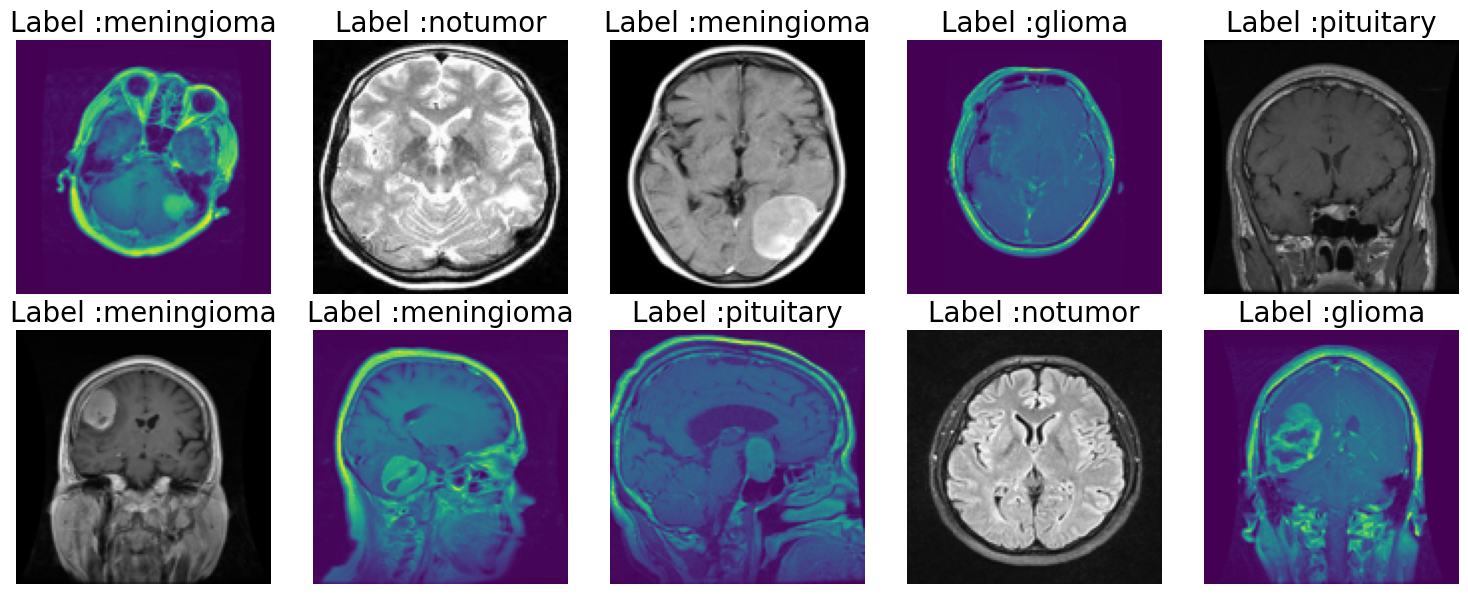

In [ ]:
from operator import index
# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Loop through the random indices and display images if wanted to see the indices no of the displayed image run it
#for i, index in enumerate(random_indices):
#  print(i, index)

for i, index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((128, 128))  #Here resizing the image from 512 to 128px

# Display images
  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(f"Label :{train_labels[index]}", fontsize =20)

plt.tight_layout()
plt.show()

# Image  Preprocessing

In [ ]:
"""
# Image Augmentation Function
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0               #Doing the normalization so that the images come between 0 and 1
  '''
    [
      [20,30,50,150,30.0,0]
      [30,40,50]
    ]                         0-255 -> low = dark , high = bright
  '''
  return image

# Loading the images in the array like format and apply augmentation
def open_images(paths):
  images = []
  for path in paths:
    image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    image = augment_image(image)
    images.append(image)
  return np.array(images)


# Encoder labels (Convert Label names to integers) Function
def encode_label(labels):
  unique_labels = os.listdir(train_dir)
  encoded = [unique_labels.index(label) for label in unique_labels]
  return encoded

# Data Generator for Batching
#Its use for time and memory saving , increase the speed and Performance
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch
  """

"\n# Image Augmentation Function\ndef augment_image(image):\n  image = Image.fromarray(np.uint8(image))\n  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))\n  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))\n  image = np.array(image)/255.0               #Doing the normalization so that the images come between 0 and 1\n  '''\n    [\n      [20,30,50,150,30.0,0]\n      [30,40,50]\n    ]                         0-255 -> low = dark , high = bright\n  '''\n  return image\n\n# Loading the images in the array like format and apply augmentation\ndef open_images(paths):\n  images = []\n  for path in paths:\n    image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))\n    image = augment_image(image)\n    images.append(image)\n  return np.array(images)\n\n\n# Encoder labels (Convert Label names to integers) Function\ndef encode_label(labels):\n  unique_labels = os.listdir(train_dir)\n  encoded = [unique_labels.index(label) for label in unique_la

In [ ]:
os.listdir(train_dir)
len(os.listdir(train_dir))

4

Transfer Learning vgg-16

In [ ]:
"""
# Model Architecture (RGB) (128,128,3)
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

#Freeze all layers of the Vgg -16 Base Model
for layer in base_model.layers:
  layer.trainable = False

#set only the last few layers
# I only want (2nd,3rd and 4th)last layer from base VGG16 model so need to unfreeze it.
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build Model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))         # Input layer
model.add(base_model)                   # VGG 16 knowledge so here the output will be in [[[[[]]]]] =[] multidimentional output
model.add(Flatten())                 # in order to covert multi dimentional output to single dimension we require flatten layer
model.add(Dropout(0.3))             # to reduce the overfitting randomly drops 30% neurons from the knowledge base

#Fully Connected layer|
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))             # Droplayer

# Output Layer which we tell to model that weather its a single classification or multiclass classification
#so we have multi class classification which will be handled by softmax layer
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

# Compile the model
model.compile(optimizer = Adam (learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

# Now Lets Train the model
#parameters
batch_size = 20
steps = int(len(train_paths)/ batch_size)
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)
"""

"\n# Model Architecture (RGB) (128,128,3)\nIMAGE_SIZE = 128\nbase_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')\n\n#Freeze all layers of the Vgg -16 Base Model\nfor layer in base_model.layers:\n  layer.trainable = False\n\n#set only the last few layers\n# I only want (2nd,3rd and 4th)last layer from base VGG16 model so need to unfreeze it.\nbase_model.layers[-2].trainable = True\nbase_model.layers[-3].trainable = True\nbase_model.layers[-4].trainable = True\n\n# Build Model\nmodel = Sequential()\nmodel.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))         # Input layer\nmodel.add(base_model)                   # VGG 16 knowledge so here the output will be in [[[[[]]]]] =[] multidimentional output\nmodel.add(Flatten())                 # in order to covert multi dimentional output to single dimension we require flatten layer\nmodel.add(Dropout(0.3))             # to reduce the overfitting randomly drops 30% neurons from the knowledge base\n\

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [ ]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1249s 4s/step - loss: 0.6789 - sparse_categorical_accuracy: 0.7293
Epoch 2/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1211s 4s/step - loss: 0.2586 - sparse_categorical_accuracy: 0.9018
Epoch 3/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1199s 4s/step - loss: 0.1774 - sparse_categorical_accuracy: 0.9307
Epoch 4/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1200s 4s/step - loss: 0.1109 - sparse_categorical_accuracy: 0.9570
Epoch 5/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1200s 4s/step - loss: 0.0861 - sparse_categorical_accuracy: 0.9646


Accuracy Plots

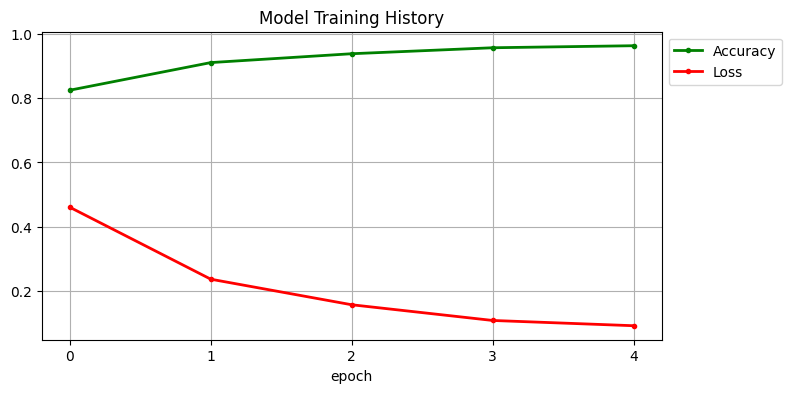

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 232s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       300
           1       0.93      0.98      0.96       300
           2       0.94      0.99      0.97       405
           3       0.88      0.87      0.87       306

    accuracy                           0.93      1311
   macro avg       0.93      0.92      0.93      1311
weighted avg       0.93      0.93      0.93      1311



Confusion Matrix:
[[256   4   5  35]
 [  1 295   2   2]
 [  2   1 401   1]
 [  5  17  18 266]]


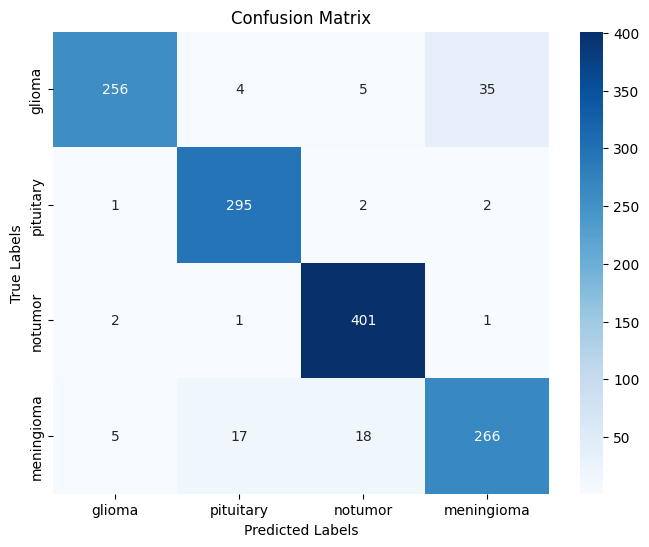

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

ROC Curve

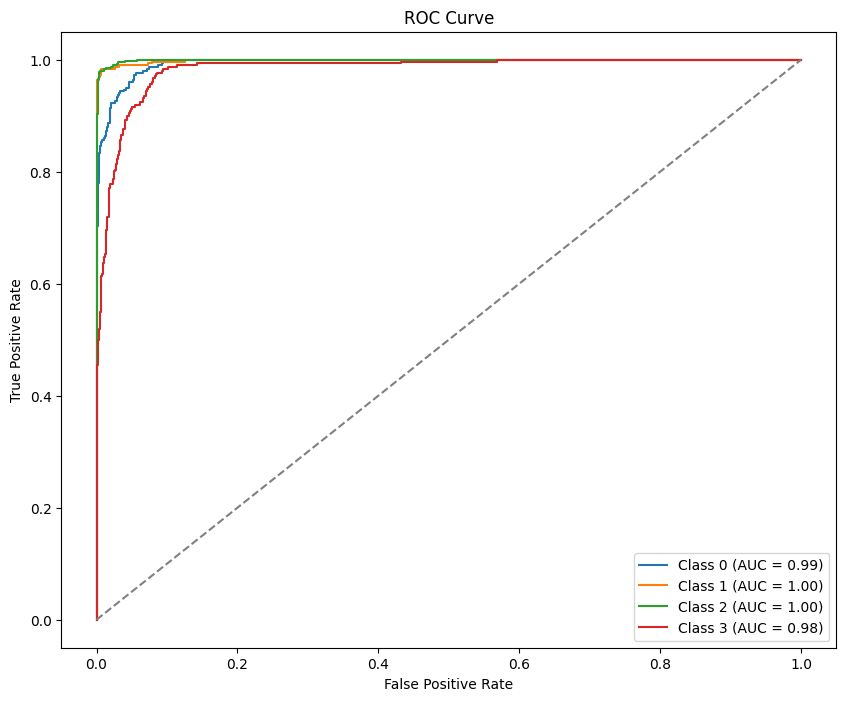

In [ ]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

Save and Load the Model

In [87]:
# Save the entire model
#model.save('model.h5')

model.save("model.keras")


In [88]:
from tensorflow.keras.models import load_model
# Load the trained model
#model = load_model('model.h5')
model = load_model("model.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Tumor Detection system

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step


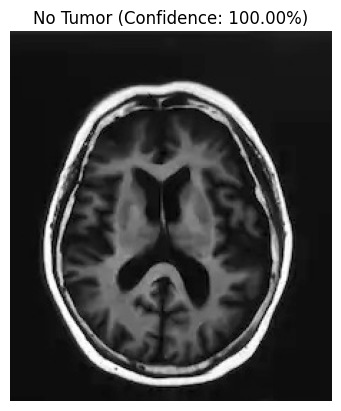

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/notumor/Te-noTr_0003.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


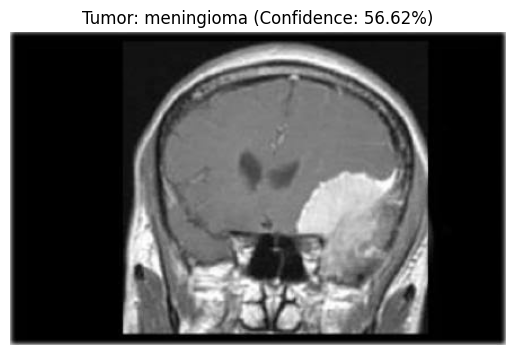

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/meningioma/Te-meTr_0000.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


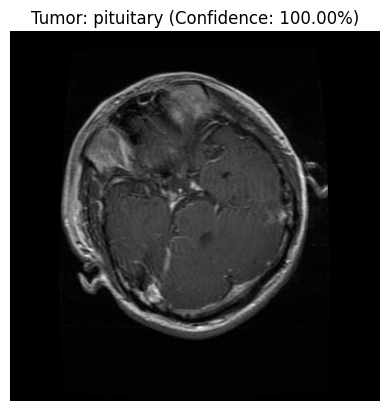

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Testing/glioma/Te-glTr_0006.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step


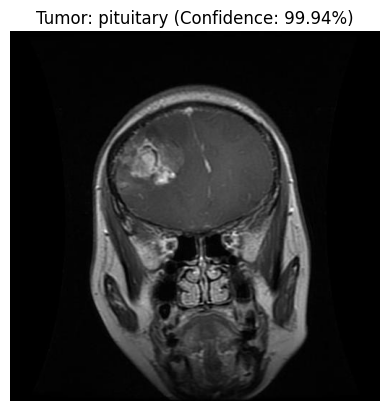

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/Brain Tumor Project/MRI Images/Training/glioma/Tr-glTr_0000.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)